#📌 Extracão

In [ ]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns

# carregando os dados do json
link = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/refs/heads/main/TelecomX_Data.json"

resp = requests.get(link)

if resp.status_code == 200:
    dados = resp.json()
    print("ok, dados carregados")
else:
    print("deu erro:", resp.status_code)

ok, dados carregados


#🔧 Transformação

In [ ]:
# expandindo os campos aninhados do json
tabela = pd.json_normalize(dados)

print(tabela.shape)
tabela.head()

(7267, 21)


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [ ]:
tabela.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [ ]:
tabela.dtypes

,0
customerID,object
Churn,object
customer.gender,object
customer.SeniorCitizen,int64
customer.Partner,object
customer.Dependents,object
customer.tenure,int64
phone.PhoneService,object
phone.MultipleLines,object
internet.InternetService,object


In [ ]:
# valores unicos em colunas importantes
for c in ['Churn', 'account.Contract', 'account.PaymentMethod']:
    print(f"{c}: {tabela[c].unique()}\n")

Churn: ['No' 'Yes']

account.Contract: ['One year' 'Month-to-month' 'Two year']

account.PaymentMethod: ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']



In [ ]:
# checando nulos e duplicatas
print(tabela.isnull().sum())
print(f"\nduplicatas: {tabela.duplicated().sum()}")

customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64

duplicatas: 0


In [ ]:
# tirando linhas onde Churn ta vazio
tabela = tabela[tabela['Churn'] != '']

# strings vazias viram NaN
tabela.replace('', np.nan, inplace=True)

# coluna de cobrança total tava como texto, convertendo pra numero
tabela['account.Charges.Total'] = pd.to_numeric(tabela['account.Charges.Total'], errors='coerce')

# conferindo nulos restantes
print(tabela.isnull().sum())
print(f"\ntotal de linhas agora: {tabela.shape[0]}")

tabela.reset_index(drop=True, inplace=True)

customerID                    0
Churn                         0
customer.gender               0
customer.SeniorCitizen        0
customer.Partner              0
customer.Dependents           0
customer.tenure               0
phone.PhoneService            0
phone.MultipleLines           0
internet.InternetService      0
internet.OnlineSecurity       0
internet.OnlineBackup         0
internet.DeviceProtection     0
internet.TechSupport          0
internet.StreamingTV          0
internet.StreamingMovies      0
account.Contract              0
account.PaperlessBilling      0
account.PaymentMethod         0
account.Charges.Monthly       0
account.Charges.Total        11
dtype: int64

total de linhas agora: 7043


In [ ]:
print("Churn valores:", tabela['Churn'].unique())
print("Tipo Charges.Total:", tabela['account.Charges.Total'].dtype)

Churn valores: ['No' 'Yes']
Tipo Charges.Total: float64


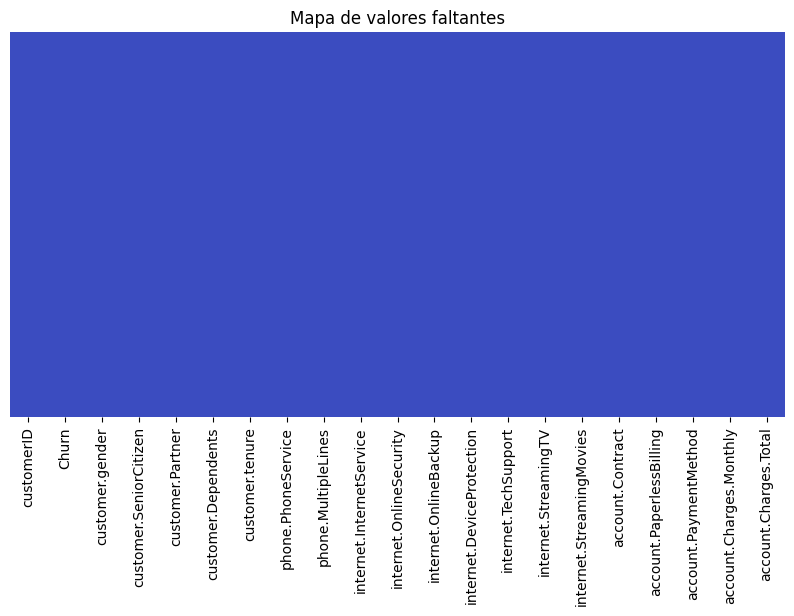

In [ ]:
plt.figure(figsize=(10, 5))
sns.heatmap(tabela.isnull(), cbar=False, yticklabels=False, cmap='coolwarm')
plt.title('Mapa de valores faltantes')
plt.show()

#📊 Carga e análise

In [ ]:
tabela.describe()

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [ ]:
print(f"Media gasto mensal: R${tabela['account.Charges.Monthly'].mean():.2f}")
print(f"Mediana gasto mensal: R${tabela['account.Charges.Monthly'].median():.2f}")

Media gasto mensal: R$64.76
Mediana gasto mensal: R$70.35


In [ ]:
# media de gasto por grupo de churn
tabela.groupby('Churn')['account.Charges.Monthly'].mean()

,account.Charges.Monthly
Churn,
No,61.265124
Yes,74.441332


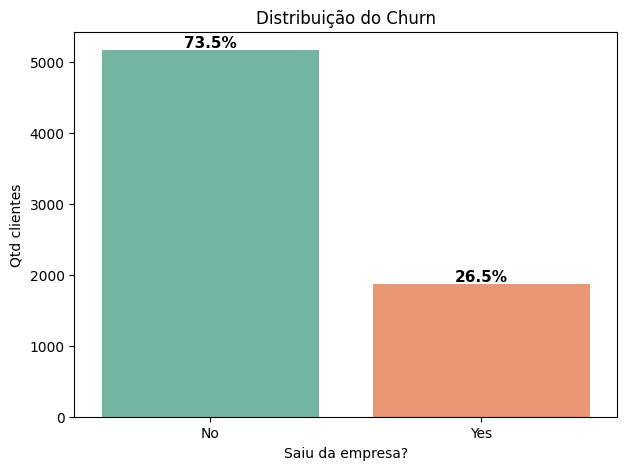

In [ ]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(x='Churn', hue='Churn', data=tabela, palette='Set2', legend=False)

tot = len(tabela)
for barra in ax.patches:
    pct = f'{100 * barra.get_height() / tot:.1f}%'
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 40,
            pct, ha='center', fontsize=11, fontweight='bold')

plt.title('Distribuição do Churn')
plt.xlabel('Saiu da empresa?')
plt.ylabel('Qtd clientes')
plt.show()

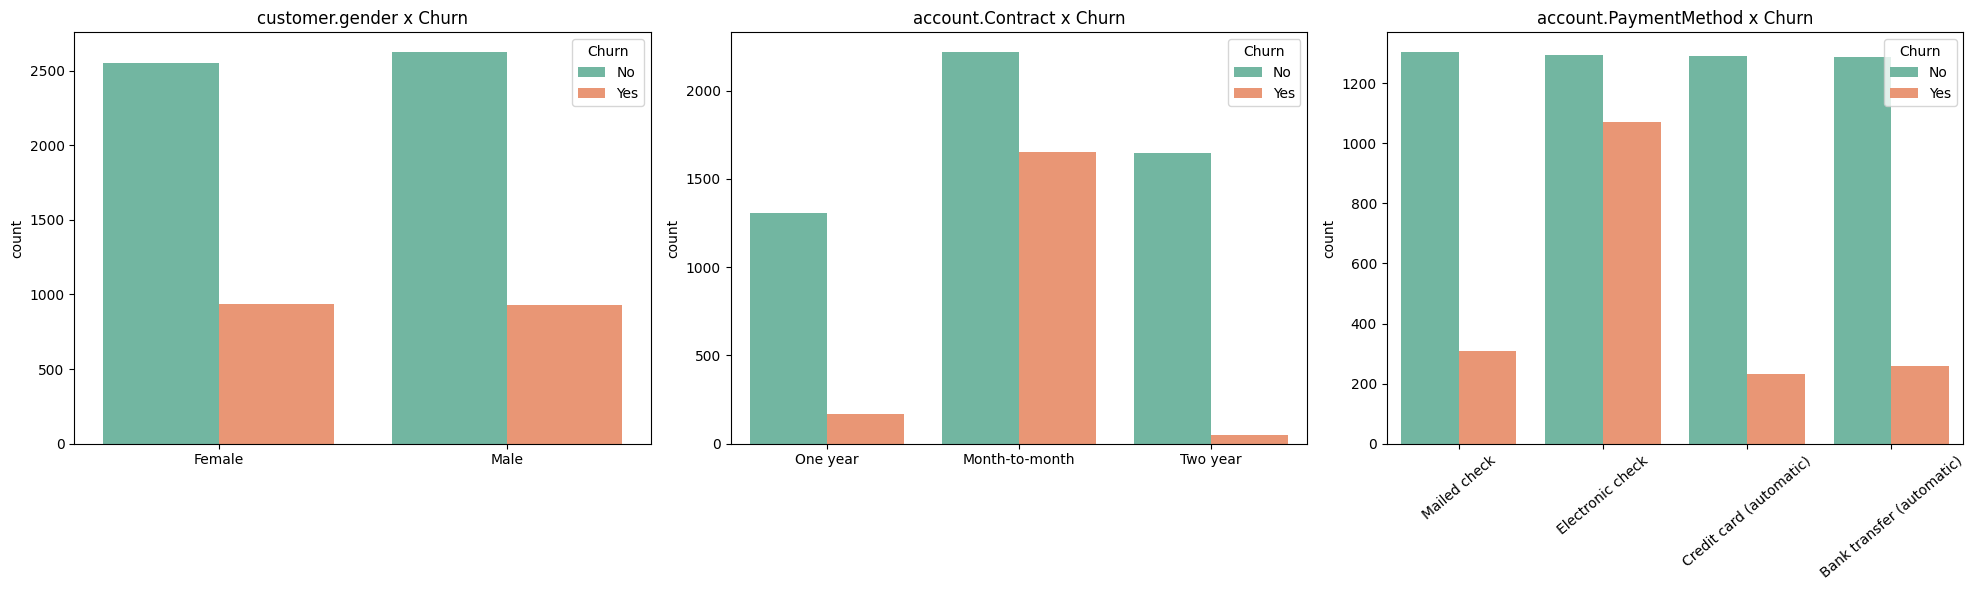

In [ ]:
cols_cat = ['customer.gender', 'account.Contract', 'account.PaymentMethod']

fig, axs = plt.subplots(1, 3, figsize=(20, 6))

for idx, coluna in enumerate(cols_cat):
    sns.countplot(x=coluna, hue='Churn', data=tabela, ax=axs[idx], palette='Set2')
    axs[idx].set_title(f'{coluna} x Churn')
    axs[idx].set_xlabel('')
    if coluna == 'account.PaymentMethod':
        axs[idx].tick_params(axis='x', rotation=40)

plt.tight_layout()
plt.show()

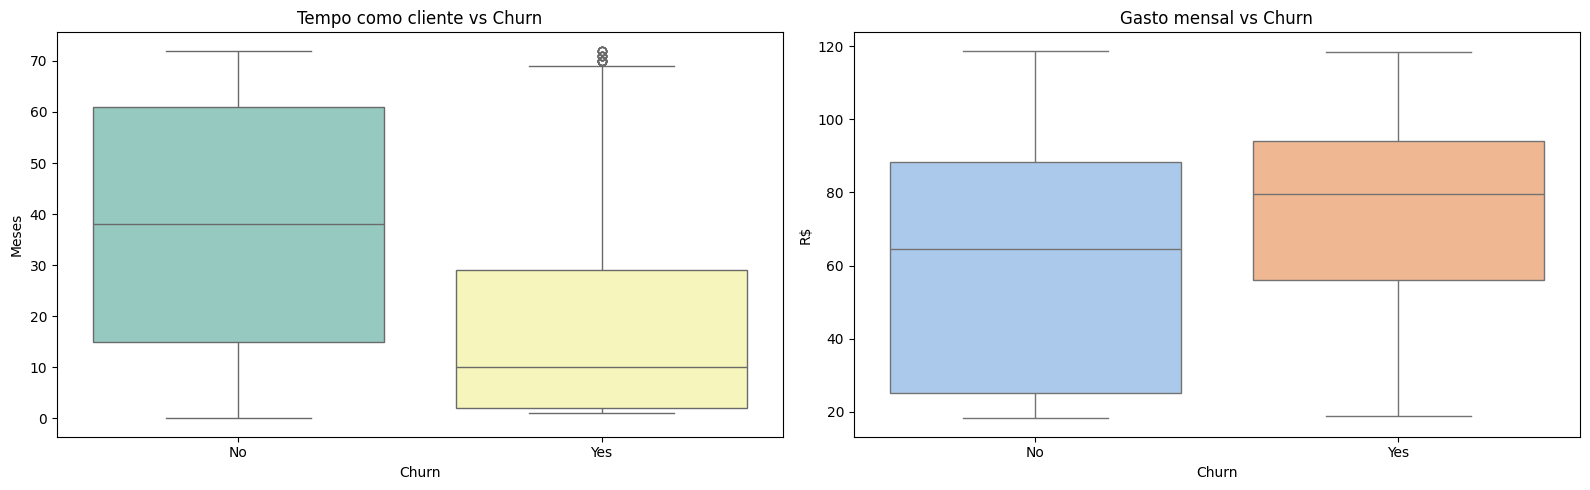

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(x='Churn', y='customer.tenure', hue='Churn', data=tabela,
            ax=axs[0], palette='Set3', legend=False)
axs[0].set_title('Tempo como cliente vs Churn')
axs[0].set_ylabel('Meses')

sns.boxplot(x='Churn', y='account.Charges.Monthly', hue='Churn', data=tabela,
            ax=axs[1], palette='pastel', legend=False)
axs[1].set_title('Gasto mensal vs Churn')
axs[1].set_ylabel('R$')

plt.tight_layout()
plt.show()

#📄Relatorio Final

## Introdução

Nesse projeto o objetivo é analisar os dados de uma empresa de telecomunicações (TelecomX) pra tentar entender **por que os clientes estão cancelando o serviço**, o famoso Churn.

A ideia aqui é passar por todo o processo de análise de dados:
- **Extrair** os dados de uma API
- **Tratar e limpar** inconsistências
- **Analisar** os dados com gráficos e estatísticas
- **Tirar conclusões** que possam ajudar a empresa

Os dados vêm de um arquivo JSON disponível no GitHub, com informações sobre clientes, contratos, cobranças e serviços contratados.

## Limpeza e Tratamento de Dados

Durante a exploração inicial dos dados, foram identificados os seguintes problemas:

| Problema | Solução aplicada |
|---|---|
| Valores vazios (`''`) na coluna Churn | Linhas removidas, pois Churn é a variável alvo |
| Strings vazias em outras colunas | Substituídas por `NaN` para o Pandas reconhecer como nulo |
| Coluna de gastos totais como texto | Convertida para tipo numérico (`float64`) |
| Valores nulos remanescentes | Verificados e tratados |

### Resultado
Após a limpeza, o dataset ficou consistente, sem valores vazios na coluna alvo e com os tipos de dados corretos para análise.

## Análise Exploratória de Dados

### 3.1 Distribuição do Churn
O primeiro passo foi verificar a proporção de clientes que saíram versus os que ficaram. O gráfico de barras mostrou que aproximadamente **26-27% dos clientes cancelaram** o serviço, o que é uma taxa considerável.

### 3.2 Gastos Mensais
A análise mostrou que clientes que cancelam pagam em média **mais caro** por mês do que os que ficam. Isso indica que o preço pode ser um fator importante na decisão de sair.

### 3.3 Tempo de Casa (Tenure)
Clientes que cancelam tendem a ter **menos tempo de casa**. Ou seja, clientes novos são mais propensos a sair do que clientes antigos. Isso faz sentido porque clientes antigos já estão acostumados com o serviço.

### 3.4 Tipo de Contrato
Clientes com contrato **mensal** cancelam muito mais do que clientes com contrato de 1 ou 2 anos. Contratos longos funcionam como uma forma de retenção.

### 3.5 Método de Pagamento
Clientes que pagam por **boleto eletrônico (Electronic Check)** apresentaram a maior taxa de evasão comparado aos outros métodos de pagamento.

### 3.6 Gênero
O gênero do cliente **não apresentou diferença significativa** na taxa de evasão. Homens e mulheres cancelam em proporções parecidas.

## Conclusões e Insights

Depois de analisar os dados, os principais achados foram:

A empresa tem cerca de 26% de evasão, ou seja, 1 em cada 4 clientes cancela.

Clientes que cancelam têm gasto mensal maior, indicando que o preço pode influenciar a decisão.

Clientes novos cancelam mais, enquanto os mais antigos tendem a permanecer.

Contratos mensais apresentam muito mais evasão do que contratos de 1 ou 2 anos.

Pagamento por boleto eletrônico (Electronic check) aparece com mais frequência entre clientes que cancelam.

Gênero não influencia na evasão, pois a distribuição entre homens e mulheres é semelhante.

## Recomendações

Com base nos insights da análise, algumas ações que a TelecomX poderia considerar:

1. **Dar atenção especial aos clientes novos (primeiros 6 meses)**: oferecer suporte proativo, descontos de boas-vindas ou acompanhamento personalizado pra reduzir a evasão nesse período crítico.

2. **Incentivar contratos de longo prazo**: criar promoções ou benefícios pra quem migrar do contrato mensal pro anual ou de 2 anos, já que esses clientes cancelam bem menos.

3. **Investigar o pagamento por Electronic Check**: entender por que esse grupo cancela mais — pode ser que o método de pagamento em si cause atrito, ou pode ser um perfil de cliente específico.